# Strategy 14 — FFT Cycle Filter & Forward Projection

End-to-end backtest of the strategy documented in [`DocumentationVault/strategies/14_FFT_Cycle_Filter.md`](../DocumentationVault/strategies/14_FFT_Cycle_Filter.md).

The notebook follows the same six-section template as the SMA / RSI baselines:

1. Load data
2. Multi-timeframe preparation
3. Strategy definition + baseline backtest
4. Walk-Forward Optimization (5 folds, 75 % IS / 25 % OOS)
5. Robustness — Monte Carlo, block bootstrap, sub-period, parameter sensitivity
6. Takeaways

**Scope deviations from the doc.** The strategy doc lists forex, b3, crypto as target markets; crypto is not present in `data/` so the notebook runs on **forex, b3** only.


**Scope deviations from the doc.**
- The dynamic phase-cycle exit and projection-reversal close are **not implemented** (`use_projection_exit`, `use_cycle_exit` are exposed but inert); needs a custom `Backtester` exit hook.
- The doc's `min_power_fraction` filter is implemented; default 0 keeps every in-band component.
- Edge stability: the in-window reconstruction uses **no Hann compensation** (since `hann ≈ 0` at the edge makes division unstable). The Hann-distorted value at `i = N-1` and the analytical projection at `i = N` are differenced — the *relative* delta is meaningful even if both are scaled by the window.
- Crypto group skipped (no local data).

**Note:** The notebook is committed *unexecuted* — run it via Jupyter / VS Code (or `jupyter nbconvert --to notebook --execute --inplace`) to populate the outputs.

In [1]:
import gc
import sys
from pathlib import Path
from collections import Counter

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from source import (
    discover_datasets, build_lazy_grid, LazyDataset,
    FFTCycleFilterStrategy, FFTCycleFilterParams,
    Backtester, compute_metrics,
    plot_backtest_dashboard, plot_wfo_dashboard, plot_robustness_dashboard,
    walk_forward, WFOResult,
    monte_carlo_trades, monte_carlo_summary,
    block_bootstrap_trades, subperiod_analysis, parameter_sensitivity,
    run_backtest_grid, run_backtests_with_params, run_wfo_grid,
    reshape_grid_results, cpu_count,
)


N_JOBS = "auto"
print(f"Parallelism budget: n_jobs={N_JOBS!r} (cpu_count={cpu_count()})")

Parallelism budget: n_jobs='auto' (cpu_count=15)


## 1. Load the data

Metadata-only discovery — no CSV is read until each `LazyDataset.load()` fires (which happens inside worker processes, not in the parent).

In [2]:
metas = discover_datasets(REPO_ROOT / "data")
print(f"Discovered {len(metas)} dataset(s):")
for (asset, tf), meta in metas.items():
    tag = f"[{meta.group}]" if meta.group else "[root]"
    print(f"  {tag:8s} {asset:10s} {tf:4s}  {meta.start.date()} -> {meta.end.date()}")

target_groups = {'crypto', 'forex', 'b3'}
present_groups = {m.group for m in metas.values()}
missing = sorted(target_groups - present_groups)
if missing:
    print(f"\n[note] Strategy targets {sorted(target_groups)} but no data present for: {missing}. Continuing with: {sorted(target_groups & present_groups)}.")

Discovered 5 dataset(s):
  [b3]     WDO        M1    2021-04-30 -> 2026-04-29
  [b3]     WIN        M1    2021-04-30 -> 2026-04-29
  [forex]  EURCAD     M1    2016-04-11 -> 2026-04-21
  [forex]  EURUSD     M1    2016-04-11 -> 2026-04-21
  [forex]  GBPCHF     M1    2016-04-11 -> 2026-04-21

[note] Strategy targets ['b3', 'crypto', 'forex'] but no data present for: ['crypto']. Continuing with: ['b3', 'forex'].


## 2. Multi-timeframe preparation

Per-group target timeframes (matching the doc's "Markets" / "Timeframes" sections):

- **FOREX** — 4h, 1D
- **B3** — 1h, 4h

`build_lazy_grid` returns `{group: {tf: {asset: LazyDataset}}}` without loading any CSV; workers materialise frames one cell at a time.

In [3]:
GROUP_TIMEFRAMES = {
    "forex": [
        "4h",
        "1D"
    ],
    "b3": [
        "1h",
        "4h"
    ]
}

group_tfs = build_lazy_grid(REPO_ROOT / "data", group_timeframes=GROUP_TIMEFRAMES)
group_tfs = {g: tfs for g, tfs in group_tfs.items() if g in GROUP_TIMEFRAMES}
if not present_groups & set(GROUP_TIMEFRAMES):
    raise RuntimeError("None of the strategy's target groups have local data.")

for group, tfs in group_tfs.items():
    print(f"\n{group.upper()}:")
    for tf, assets in tfs.items():
        print(f"  {tf:6s}  assets={list(assets)}")


B3:
  1h      assets=['WDO', 'WIN']
  4h      assets=['WDO', 'WIN']

FOREX:
  4h      assets=['EURCAD', 'EURUSD', 'GBPCHF']
  1D      assets=['EURCAD', 'EURUSD', 'GBPCHF']


## 3. Strategy definition — FFT Cycle Filter & Forward Projection

**Pipeline (per bar `t`)**
1. Take the last `fft_window` log-closes; detrend (linear) and Hann-window.
2. Real FFT → keep frequencies in the period band `[min_cycle_bars, max_cycle_bars]` (optionally only the top `n_harmonics` by power).
3. Project one bar ahead: each kept harmonic's contribution at `i=N` is `cos(φ)` (since `cos(2π·f·N/N+φ) = cos(φ)` for integer `f`); add the linear-trend extrapolation back.
4. `Δ(t) = x_projected − x_filtered[N-1]`.

**Entry**
- Long when `Δ(t) > delta_min_atr × ATR_log` AND `Δ(t-1) ≤ 0` (fresh sign shift, above the ATR-scaled noise floor).
- Short when `Δ(t) < -delta_min_atr × ATR_log` AND `Δ(t-1) ≥ 0`.
- `ATR_log = ATR / close` (Δ is in log-price; ATR is in price — convert for comparability).

**Exit (via Backtester)**
- Hard SL/TP at `entry ± atr_mult × ATR_entry`.
- Opposite fresh shift reverses the position.

**Constraint**
- `min_cycle_bars < max_cycle_bars < fft_window / 2` (Nyquist). Invalid combos emit zero signals.

Per-group baseline parameters:

| Parameter | Default |
|-----------|---------|
| `fft_window` | `128` |
| `min_cycle_bars` | `8` |
| `max_cycle_bars` | `64` |
| `n_harmonics` | `0` |
| `delta_min_atr` | `0.1` |
| `atr_period` | `14` |
| `sl_atr_mult` | `2.0` |
| `tp_atr_mult` | `3.0` |
| `min_power_fraction` | `0.0` |

In [4]:
_base_kwargs = dict(fft_window=128, min_cycle_bars=8, max_cycle_bars=64, n_harmonics=0, delta_min_atr=0.1, atr_period=14, sl_atr_mult=2.0, tp_atr_mult=3.0, min_power_fraction=0.0)
baseline_params_by_group = {
    "forex": FFTCycleFilterParams(**_base_kwargs),
    "b3": FFTCycleFilterParams(**dict(_base_kwargs, session_start=9, session_end=18)),
}
# Fall back: use the first group's params for groups without an override
_default_params = next(iter(baseline_params_by_group.values()))
def _params_for(group):
    return baseline_params_by_group.get(group, _default_params)
baseline_params = _default_params  # default used by the §4 WFO grid

SUMMARY_METRICS = [
    "num_trades", "total_pnl", "win_rate", "profit_factor",
    "expectancy", "max_drawdown", "sharpe_daily", "sharpe_per_trade", "p_value",
]


class _PortfolioResult:
    def __init__(self, trades, equity):
        self.trades = trades
        self.equity = equity


def build_portfolio(per_asset_results):
    frames = []
    for asset, result in per_asset_results.items():
        if not result.trades.empty:
            t = result.trades.copy()
            t.insert(0, "asset", asset)
            frames.append(t)
    if not frames:
        return _PortfolioResult(pd.DataFrame(), pd.Series(dtype=float))
    combined = (pd.concat(frames, ignore_index=True)
                .sort_values("exit_time").reset_index(drop=True))
    equity = pd.Series(combined["pnl_points"].cumsum().values,
                       index=pd.to_datetime(combined["exit_time"].values),
                       name="equity_points")
    return _PortfolioResult(combined, equity)


def metrics_comparison(portfolio_dict, keys=None):
    keys = keys or SUMMARY_METRICS
    rows = {}
    for tf, portfolio in portfolio_dict.items():
        m = compute_metrics(portfolio)
        rows[tf] = {k: m[k] for k in keys if k in m}
    return pd.DataFrame(rows)


In [5]:
flat_results = {}
for group, tfs_for_group in group_tfs.items():
    sub_grid = {group: tfs_for_group}
    flat_sub = run_backtest_grid(sub_grid, _params_for(group),
        strategy_cls=FFTCycleFilterStrategy, n_jobs=N_JOBS, progress=False)
    flat_results.update(flat_sub)
baseline_per_asset = reshape_grid_results(flat_results)
baseline_portfolio = {
    g: {tf: build_portfolio(by_asset) for tf, by_asset in tfs.items()}
    for g, tfs in baseline_per_asset.items()
}

for group in baseline_portfolio:
    for tf, portfolio in baseline_portfolio[group].items():
        n = len(portfolio.trades) if not portfolio.trades.empty else 0
        print(f"{group:5s}  {tf:6s}  {n:>6,} trades")

b3     1h           0 trades
b3     4h           0 trades
forex  4h           0 trades
forex  1D           0 trades


### 3.1 FOREX — baseline across timeframes

Portfolio metrics across timeframes, per-asset breakdown, and equity dashboards.

In [6]:
if "forex" in baseline_portfolio:
    print("Portfolio metrics — FOREX (all assets, per timeframe):")
    display(metrics_comparison(baseline_portfolio["forex"]))
    print("\nPer-asset breakdown by timeframe:")
    for tf, asset_results in baseline_per_asset["forex"].items():
        print(f"\n  {tf}:")
        detail = {asset: compute_metrics(r) for asset, r in asset_results.items()}
        display(pd.DataFrame(detail).loc[
            ["num_trades", "total_pnl", "sharpe_daily", "profit_factor", "max_drawdown"]
        ])
    for tf, portfolio in baseline_portfolio["forex"].items():
        if portfolio.trades.empty:
            print(f"  {tf}: no trades — skipping")
            continue
        fig = plot_backtest_dashboard(portfolio, title=f"FOREX baseline — {tf}")
        plt.show()

Portfolio metrics — FOREX (all assets, per timeframe):


,4h,1D
num_trades,0.0,0.0
total_pnl,0.0,0.0
win_rate,NaN,NaN
profit_factor,NaN,NaN
expectancy,NaN,NaN
max_drawdown,0.0,0.0
sharpe_daily,NaN,NaN
sharpe_per_trade,NaN,NaN
p_value,NaN,NaN



Per-asset breakdown by timeframe:

  4h:


,EURCAD,EURUSD,GBPCHF
num_trades,0.0,0.0,0.0
total_pnl,0.0,0.0,0.0
sharpe_daily,NaN,NaN,NaN
profit_factor,NaN,NaN,NaN
max_drawdown,0.0,0.0,0.0



  1D:


,EURCAD,EURUSD,GBPCHF
num_trades,0.0,0.0,0.0
total_pnl,0.0,0.0,0.0
sharpe_daily,NaN,NaN,NaN
profit_factor,NaN,NaN,NaN
max_drawdown,0.0,0.0,0.0


  4h: no trades — skipping
  1D: no trades — skipping


### 3.2 B3 — baseline across timeframes

Portfolio metrics across timeframes, per-asset breakdown, and equity dashboards.

In [7]:
if "b3" in baseline_portfolio:
    print("Portfolio metrics — B3 (all assets, per timeframe):")
    display(metrics_comparison(baseline_portfolio["b3"]))
    print("\nPer-asset breakdown by timeframe:")
    for tf, asset_results in baseline_per_asset["b3"].items():
        print(f"\n  {tf}:")
        detail = {asset: compute_metrics(r) for asset, r in asset_results.items()}
        display(pd.DataFrame(detail).loc[
            ["num_trades", "total_pnl", "sharpe_daily", "profit_factor", "max_drawdown"]
        ])
    for tf, portfolio in baseline_portfolio["b3"].items():
        if portfolio.trades.empty:
            print(f"  {tf}: no trades — skipping")
            continue
        fig = plot_backtest_dashboard(portfolio, title=f"B3 baseline — {tf}")
        plt.show()

Portfolio metrics — B3 (all assets, per timeframe):


,1h,4h
num_trades,0.0,0.0
total_pnl,0.0,0.0
win_rate,NaN,NaN
profit_factor,NaN,NaN
expectancy,NaN,NaN
max_drawdown,0.0,0.0
sharpe_daily,NaN,NaN
sharpe_per_trade,NaN,NaN
p_value,NaN,NaN



Per-asset breakdown by timeframe:

  1h:


,WDO,WIN
num_trades,0.0,0.0
total_pnl,0.0,0.0
sharpe_daily,NaN,NaN
profit_factor,NaN,NaN
max_drawdown,0.0,0.0



  4h:


,WDO,WIN
num_trades,0.0,0.0
total_pnl,0.0,0.0
sharpe_daily,NaN,NaN
profit_factor,NaN,NaN
max_drawdown,0.0,0.0


  1h: no trades — skipping
  4h: no trades — skipping


## 4. Walk-Forward Optimization

Each (group, timeframe, asset) runs an independent WFO with `n_splits=5` and `oos_ratio=0.25`. In-sample objective: maximize daily Sharpe.

WFO grid (trimmed for FFT cost — every cell does an O(N log N) FFT per bar):

| Parameter | Values |
|-----------|--------|
| `fft_window` | [64, 128] |
| `min_cycle_bars` | [6, 8] |
| `max_cycle_bars` | [32, 48] |
| `n_harmonics` | [0, 3, 5] |
| `delta_min_atr` | [0.05, 0.1, 0.2] |
| `sl_atr_mult` | [1.5, 2.0, 2.5] |
| `tp_atr_mult` | [2.0, 3.0, 4.0] |

In [8]:
param_grid = {
    "fft_window": [
        64,
        128
    ],
    "min_cycle_bars": [
        6,
        8
    ],
    "max_cycle_bars": [
        32,
        48
    ],
    "n_harmonics": [
        0,
        3,
        5
    ],
    "delta_min_atr": [
        0.05,
        0.1,
        0.2
    ],
    "sl_atr_mult": [
        1.5,
        2.0,
        2.5
    ],
    "tp_atr_mult": [
        2.0,
        3.0,
        4.0
    ]
}


def build_combined_wfo(wfo_per_asset_tf):
    _oos_frames = []
    for asset, wfo in wfo_per_asset_tf.items():
        if not wfo.oos_trades.empty:
            t = wfo.oos_trades.copy()
            t.insert(0, "asset", asset)
            _oos_frames.append(t)
    if not _oos_frames:
        return WFOResult(windows=pd.DataFrame(),
                         oos_equity=pd.Series(dtype=float),
                         oos_trades=pd.DataFrame())
    combined_oos = (pd.concat(_oos_frames, ignore_index=True)
                    .sort_values("exit_time").reset_index(drop=True))
    oos_equity = pd.Series(combined_oos["pnl_points"].cumsum().values,
                           index=pd.to_datetime(combined_oos["exit_time"].values),
                           name="equity_points")
    sample_wfo = next(iter(wfo_per_asset_tf.values()))
    fold_rows = []
    if "fold" in combined_oos.columns and not sample_wfo.windows.empty:
        fold_nums = sorted(combined_oos["fold"].unique())
        avg_deg = {}
        for fn in fold_nums:
            degs = []
            for wfo in wfo_per_asset_tf.values():
                if wfo.windows.empty or "degradation_ratio" not in wfo.windows.columns:
                    continue
                fw = wfo.windows[wfo.windows["fold"] == fn]
                if not fw.empty and pd.notna(fw.iloc[0]["degradation_ratio"]):
                    degs.append(float(fw.iloc[0]["degradation_ratio"]))
            avg_deg[fn] = float(np.nanmean(degs)) if degs else np.nan
        for fold_num in fold_nums:
            _ft = combined_oos[combined_oos["fold"] == fold_num].sort_values("exit_time")
            _feq = pd.Series(_ft["pnl_points"].cumsum().values,
                             index=pd.to_datetime(_ft["exit_time"].values))
            _fm = compute_metrics(_PortfolioResult(_ft, _feq))
            _bnd = sample_wfo.windows[sample_wfo.windows["fold"] == fold_num].iloc[0]
            param_cols = {k: v for k, v in _bnd.items() if str(k).startswith("param_")}
            fold_rows.append({
                "fold": fold_num,
                "is_start": _bnd["is_start"],  "is_end": _bnd["is_end"],
                "oos_start": _bnd["oos_start"], "oos_end": _bnd["oos_end"],
                "oos_pnl": _fm["total_pnl"], "oos_sharpe": _fm["sharpe_daily"],
                "oos_profit_factor": _fm["profit_factor"],
                "oos_win_rate": _fm["win_rate"], "oos_trades": _fm["num_trades"],
                "degradation_ratio": avg_deg.get(fold_num, np.nan),
                **param_cols,
            })
    return WFOResult(windows=pd.DataFrame(fold_rows),
                     oos_equity=oos_equity,
                     oos_trades=combined_oos)


flat_wfo = {}
for group, tfs_for_group in group_tfs.items():
    sub_grid = {group: tfs_for_group}
    flat_sub = run_wfo_grid(sub_grid, param_grid=param_grid,
        n_splits=5, oos_ratio=0.25,
        strategy_cls=FFTCycleFilterStrategy, params_cls=FFTCycleFilterParams,
        n_jobs=N_JOBS, inner_n_jobs=1, progress=False)
    flat_wfo.update(flat_sub)
wfo_per_asset = reshape_grid_results(flat_wfo)
wfo_combined = {
    g: {tf: build_combined_wfo(by_asset) for tf, by_asset in tfs.items()}
    for g, tfs in wfo_per_asset.items()
}

for group in wfo_combined:
    for tf, wfo in wfo_combined[group].items():
        print(f"{group:5s}  {tf:6s}  {len(wfo.oos_trades):>6,} OOS trades")

b3     1h          37 OOS trades
b3     4h          10 OOS trades
forex  4h          93 OOS trades
forex  1D           0 OOS trades


### 4.1 FOREX — WFO out-of-sample

OOS portfolio metrics — FOREX (per timeframe):


,4h
num_trades,93.000000
total_pnl,0.073750
win_rate,0.526882
profit_factor,1.418814
expectancy,0.000793
max_drawdown,-0.029060
sharpe_daily,0.427495
sharpe_per_trade,1.410072
p_value,0.158518


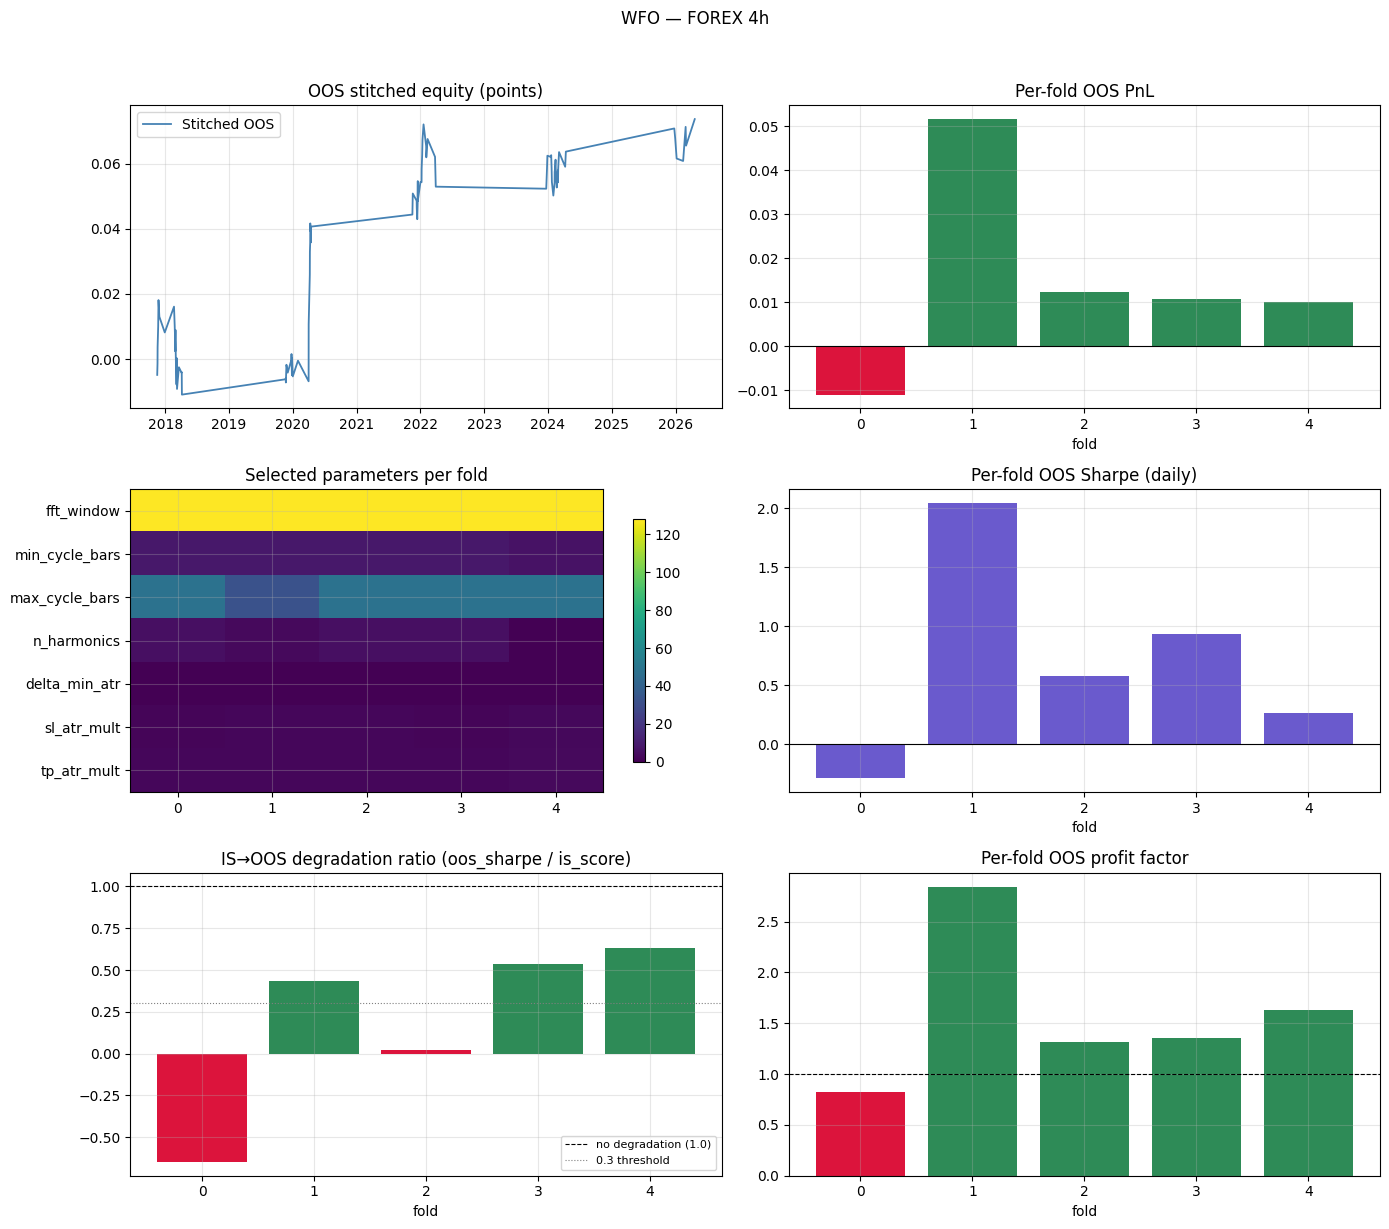

In [9]:
if "forex" in wfo_combined:
    oos_ports = {tf: _PortfolioResult(w.oos_trades, w.oos_equity)
                  for tf, w in wfo_combined["forex"].items() if not w.oos_trades.empty}
    if oos_ports:
        print("OOS portfolio metrics — FOREX (per timeframe):")
        display(metrics_comparison(oos_ports))
    for tf, wfo in wfo_combined["forex"].items():
        if wfo.oos_trades.empty:
            continue
        baseline_eq = baseline_portfolio["forex"][tf].equity
        fig = plot_wfo_dashboard(wfo, full_equity=baseline_eq)
        fig.suptitle(f"WFO — FOREX {tf}", y=1.02)
        plt.show()

### 4.2 B3 — WFO out-of-sample

OOS portfolio metrics — B3 (per timeframe):


,1h,4h
num_trades,37.000000,10.000000
total_pnl,-2810.236857,-1725.195500
win_rate,0.432432,0.400000
profit_factor,0.767037,0.737153
expectancy,-75.952347,-172.519550
max_drawdown,-5015.052571,-3360.571429
sharpe_daily,-0.072219,0.124981
sharpe_per_trade,-0.456914,-0.308516
p_value,0.647733,0.757690


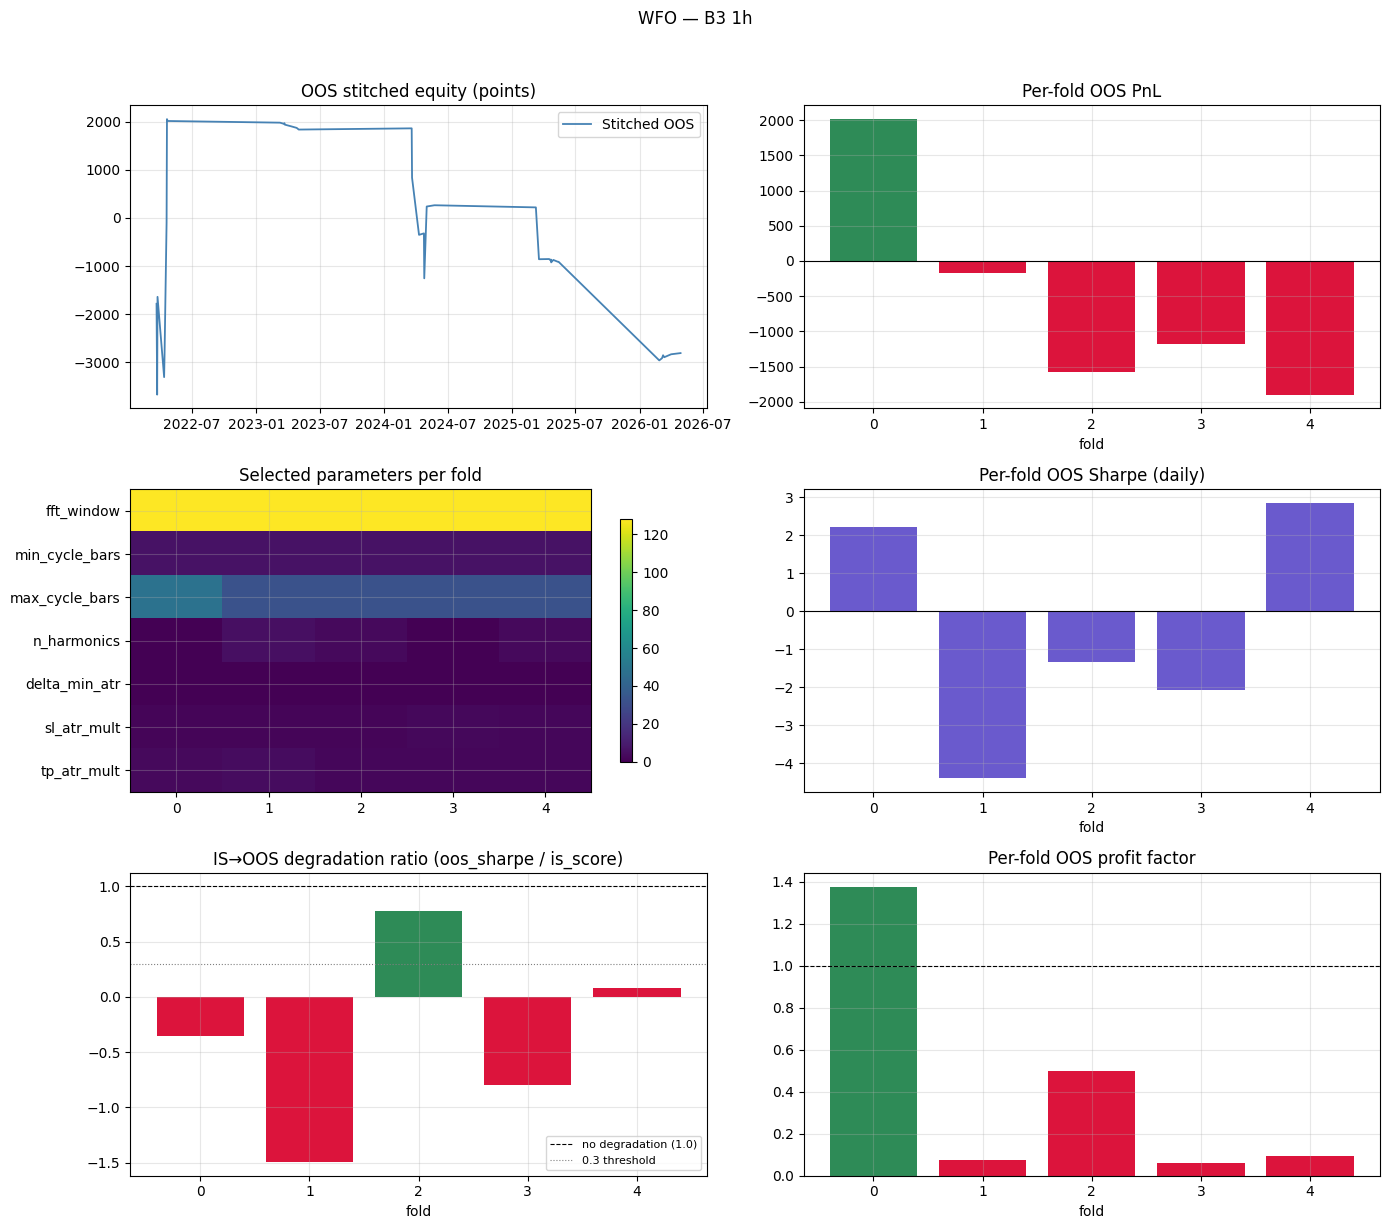

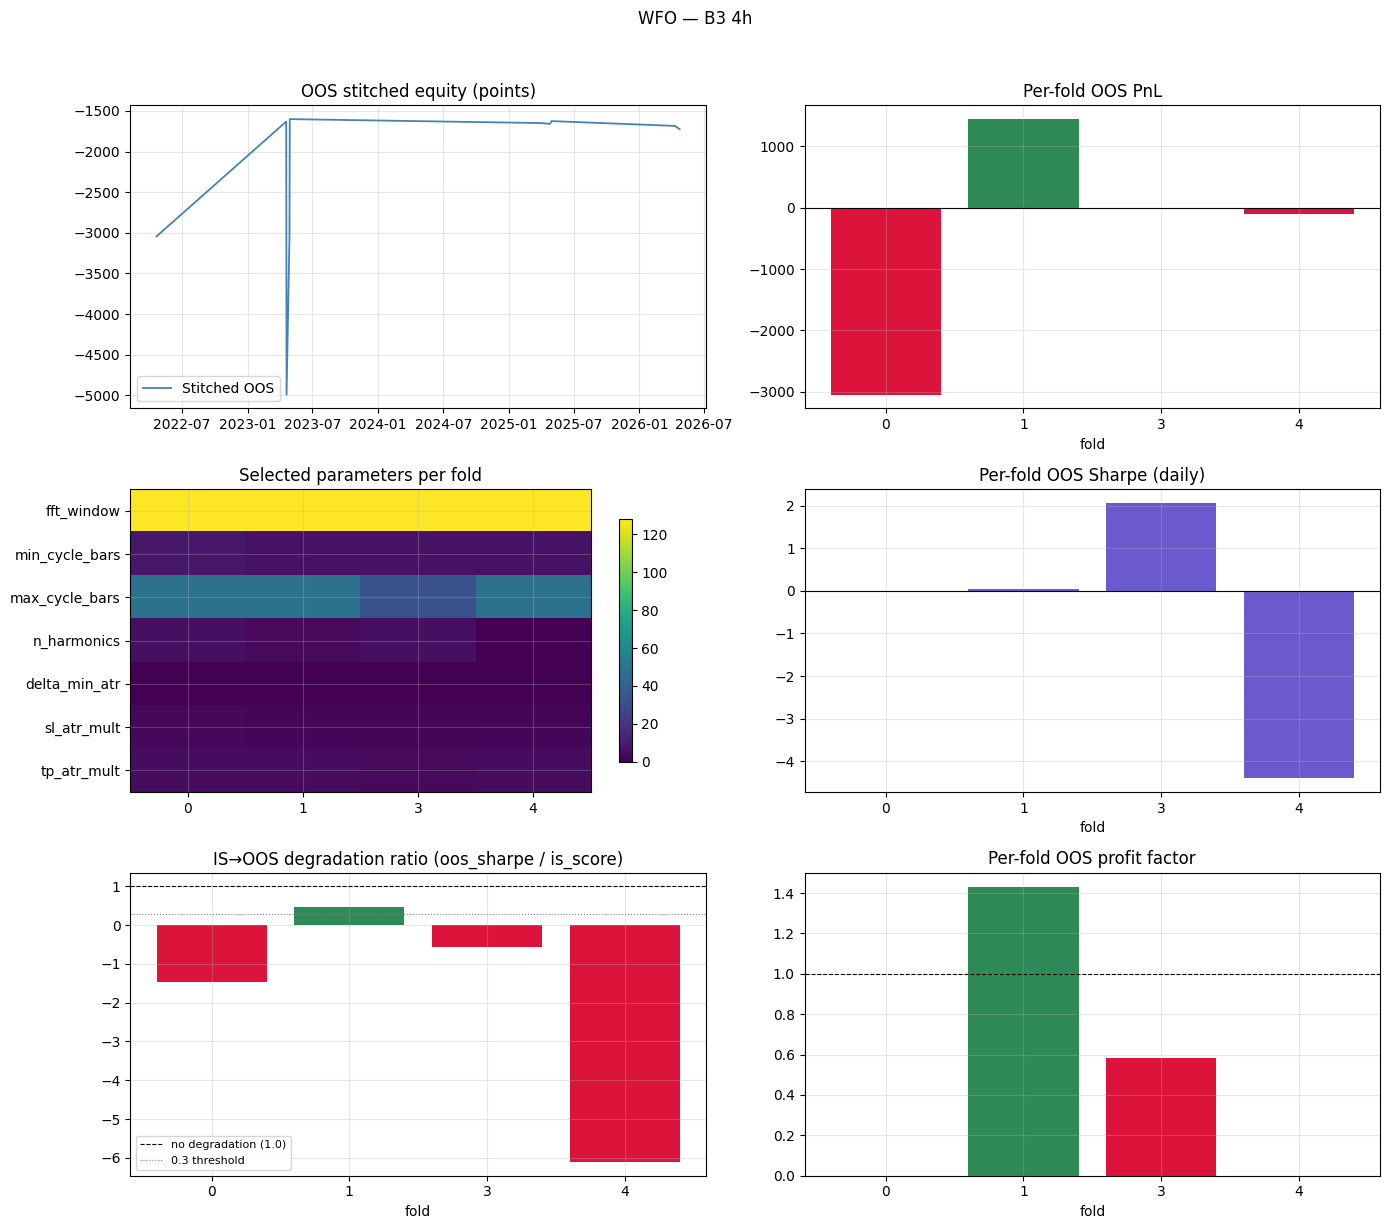

In [10]:
if "b3" in wfo_combined:
    oos_ports = {tf: _PortfolioResult(w.oos_trades, w.oos_equity)
                  for tf, w in wfo_combined["b3"].items() if not w.oos_trades.empty}
    if oos_ports:
        print("OOS portfolio metrics — B3 (per timeframe):")
        display(metrics_comparison(oos_ports))
    for tf, wfo in wfo_combined["b3"].items():
        if wfo.oos_trades.empty:
            continue
        baseline_eq = baseline_portfolio["b3"][tf].equity
        fig = plot_wfo_dashboard(wfo, full_equity=baseline_eq)
        fig.suptitle(f"WFO — B3 {tf}", y=1.02)
        plt.show()

### 4.X WFO-optimized full-history backtest

Pick the most-frequent param combo across folds per (group, tf, asset), then run a full-history backtest with that combo.

In [11]:
_INT_FIELDS = {'n_harmonics', 'max_cycle_bars', 'min_cycle_bars', 'atr_period', 'fft_window'}


def pick_best_params(wfo_windows, fallback):
    if wfo_windows.empty:
        return fallback
    pcols = [c for c in wfo_windows.columns if c.startswith("param_")]
    tuples = [tuple(row[c] for c in pcols) for _, row in wfo_windows.iterrows()]
    best = Counter(tuples).most_common(1)[0][0]
    kw = {c.replace("param_", ""): v for c, v in zip(pcols, best)}
    for k in list(kw):
        if k in _INT_FIELDS:
            kw[k] = int(kw[k])
        else:
            try:
                kw[k] = float(kw[k])
            except (TypeError, ValueError):
                pass
    # Merge with fallback's full attrs so non-WFO params (e.g. session) are preserved
    base = fallback.as_dict()
    base.update(kw)
    return FFTCycleFilterParams(**base)


optimized_params = {}
params_by_key = {}
for group, tfs in wfo_per_asset.items():
    fallback = _params_for(group)
    optimized_params[group] = {}
    for tf, by_asset in tfs.items():
        optimized_params[group][tf] = {}
        for asset, wfo in by_asset.items():
            p = pick_best_params(wfo.windows, fallback)
            optimized_params[group][tf][asset] = p
            params_by_key[(group, tf, asset)] = p

flat_opt = {}
for group, tfs_for_group in group_tfs.items():
    sub_grid = {group: tfs_for_group}
    cell_keys = {(g, tf, asset) for g, tfd in sub_grid.items()
                 for tf, ad in tfd.items() for asset in ad}
    sub_pbk = {k: params_by_key[k] for k in cell_keys if k in params_by_key}
    if not sub_pbk:
        continue
    flat_sub = run_backtests_with_params(sub_grid, sub_pbk,
        strategy_cls=FFTCycleFilterStrategy, n_jobs=N_JOBS, progress=False)
    flat_opt.update(flat_sub)
opt_per_asset = reshape_grid_results(flat_opt)
optimized_portfolio = {
    g: {tf: build_portfolio(by_asset) for tf, by_asset in tfs.items()}
    for g, tfs in opt_per_asset.items()
}

for group in optimized_portfolio:
    print(f"Optimized full-history portfolio metrics — {group.upper()}:")
    display(metrics_comparison(optimized_portfolio[group]))
    opt_rows = []
    for tf, by_asset in optimized_params[group].items():
        for asset, params in by_asset.items():
            row = {"tf": tf, "asset": asset}
            row.update({k: v for k, v in params.as_dict().items() if k in ['fft_window', 'min_cycle_bars', 'max_cycle_bars', 'n_harmonics', 'delta_min_atr', 'sl_atr_mult', 'tp_atr_mult'] })
            opt_rows.append(row)
    if opt_rows:
        print(f"\nWFO-picked params per (TF, asset) — {group.upper()}:")
        display(pd.DataFrame(opt_rows).set_index(["tf", "asset"]))

Optimized full-history portfolio metrics — B3:


,1h,4h
num_trades,208.000000,121.000000
total_pnl,22024.810214,-12066.357286
win_rate,0.528846,0.512397
profit_factor,1.406783,0.694288
expectancy,105.888511,-99.721961
max_drawdown,-12586.390107,-15331.746429
sharpe_daily,0.443438,-0.406874
sharpe_per_trade,1.339926,-1.051624
p_value,0.180270,0.292972



WFO-picked params per (TF, asset) — B3:


fft_window  min_cycle_bars  max_cycle_bars  n_harmonics  \
tf asset                                                            
1h WDO           128               6              48            0   
   WIN           128               6              32            0   
4h WDO           128               8              48            5   
   WIN           128               8              32            5   

          delta_min_atr  sl_atr_mult  tp_atr_mult  
tf asset                                           
1h WDO             0.05          1.5          3.0  
   WIN             0.05          2.0          3.0  
4h WDO             0.05          2.5          4.0  
   WIN             0.05          2.0          2.0

Optimized full-history portfolio metrics — FOREX:


,4h,1D
num_trades,366.000000,64.000000
total_pnl,0.180292,0.173650
win_rate,0.532787,0.562500
profit_factor,1.208909,1.426835
expectancy,0.000493,0.002713
max_drawdown,-0.105575,-0.088467
sharpe_daily,0.444596,0.308495
sharpe_per_trade,1.644178,1.233105
p_value,0.100139,0.217536



WFO-picked params per (TF, asset) — FOREX:


fft_window  min_cycle_bars  max_cycle_bars  n_harmonics  \
tf asset                                                             
4h EURCAD         128               8              48            5   
   EURUSD         128               8              48            5   
   GBPCHF         128               6              48            0   
1D EURCAD         128               6              32            0   
   EURUSD         128               6              32            5   
   GBPCHF         128               6              32            5   

           delta_min_atr  sl_atr_mult  tp_atr_mult  
tf asset                                            
4h EURCAD           0.10          1.5          2.0  
   EURUSD           0.05          2.5          2.0  
   GBPCHF           0.05          1.5          2.0  
1D EURCAD           0.05          1.5          4.0  
   EURUSD           0.10          2.5          2.0  
   GBPCHF           0.10          2.5          4.0

## 5. Robustness

For each group, the timeframe with the highest OOS daily Sharpe (from §4) is selected automatically for robustness:
1. Monte-Carlo trade-order shuffling (1,000 runs)
2. Block bootstrap (1,000 runs)
3. Sub-period analysis (annual)
4. Parameter sensitivity — one-at-a-time sweeps around the WFO-picked params

In [12]:
def best_oos_tf(group):
    best_tf_name, best_sharpe = None, -np.inf
    for tf, wfo in wfo_combined[group].items():
        if wfo.oos_trades.empty:
            continue
        port = _PortfolioResult(wfo.oos_trades, wfo.oos_equity)
        m = compute_metrics(port)
        s = m.get("sharpe_daily", np.nan)
        if not np.isnan(s) and s > best_sharpe:
            best_sharpe = s
            best_tf_name = tf
    return best_tf_name, best_sharpe


best_tfs = {g: best_oos_tf(g)[0] for g in group_tfs}
print("Selected best-OOS timeframes for robustness:", best_tfs)

variations = {
    "fft_window": [
        64,
        128
    ],
    "min_cycle_bars": [
        6,
        8
    ],
    "max_cycle_bars": [
        32,
        48
    ],
    "n_harmonics": [
        0,
        3,
        5
    ],
    "delta_min_atr": [
        0.05,
        0.1,
        0.2
    ],
    "sl_atr_mult": [
        1.5,
        2.0,
        2.5
    ],
    "tp_atr_mult": [
        2.0,
        3.0,
        4.0
    ]
}

mc_results = {}
bootstrap_results = {}
subperiod_results = {}
sensitivity_results = {}

for group, tf in best_tfs.items():
    if tf is None:
        print(f"  [skip] {group}: no positive-Sharpe OOS TF")
        continue
    opt_port = optimized_portfolio[group][tf]
    if opt_port.trades.empty:
        print(f"  [skip] {group} {tf}: no optimized trades")
        continue
    print(f"\nRobustness — {group} {tf}  ({len(opt_port.trades)} trades)")

    mc = monte_carlo_trades(opt_port.trades, n_runs=1000, seed=42)
    mc_results[group] = (mc, monte_carlo_summary(mc))
    print("  monte carlo:", {k: round(v, 4) for k, v in mc_results[group][1].items()})

    bs = block_bootstrap_trades(opt_port.trades, n_runs=1000, seed=42)
    bootstrap_results[group] = (bs, monte_carlo_summary(bs))
    print("  block bootstrap:", {k: round(v, 4) for k, v in bootstrap_results[group][1].items()})

    subperiod_results[group] = subperiod_analysis(opt_port.trades, freq="YE")

    asset0 = next(iter(group_tfs[group][tf]))
    base_p = optimized_params[group][tf][asset0]
    with group_tfs[group][tf][asset0].using() as df0:
        sensitivity_results[group] = parameter_sensitivity(
            df0, base_p, variations,
            strategy_cls=FFTCycleFilterStrategy,
            n_jobs=N_JOBS,
        )
    gc.collect()

Selected best-OOS timeframes for robustness: {'b3': '4h', 'forex': '4h'}

Robustness — b3 4h  (121 trades)
  monte carlo: {'mean_final_pnl': -12066.3573, 'median_final_pnl': -12066.3573, 'p05_final_pnl': -12066.3573, 'p95_final_pnl': -12066.3573, 'mean_max_drawdown': -17489.8272, 'p95_max_drawdown': -23170.676, 'prob_profitable': 0.0}
  block bootstrap: {'mean_final_pnl': -12649.6558, 'median_final_pnl': -12975.8655, 'p05_final_pnl': -33826.8819, 'p95_final_pnl': 8351.8244, 'mean_max_drawdown': -20460.8905, 'p95_max_drawdown': -38105.3404, 'prob_profitable': 0.165}

Robustness — forex 4h  (366 trades)
  monte carlo: {'mean_final_pnl': 0.1803, 'median_final_pnl': 0.1803, 'p05_final_pnl': 0.1803, 'p95_final_pnl': 0.1803, 'mean_max_drawdown': -0.0765, 'p95_max_drawdown': -0.1139, 'prob_profitable': 1.0}
  block bootstrap: {'mean_final_pnl': 0.1872, 'median_final_pnl': 0.1851, 'p05_final_pnl': -0.0098, 'p95_final_pnl': 0.3898, 'mean_max_drawdown': -0.0862, 'p95_max_drawdown': -0.1478, 'pro

In [13]:
for group, sub_df in subperiod_results.items():
    if sub_df.empty:
        continue
    print(f"\nSub-period (yearly) metrics — {group} {best_tfs[group]}:")
    display(sub_df[["num_trades", "total_pnl", "sharpe_daily", "profit_factor", "win_rate"]].round(3))


Sub-period (yearly) metrics — b3 4h:


,num_trades,total_pnl,sharpe_daily,profit_factor,win_rate
period,,,,,
2021,12,-2456.275,-0.899,0.508,0.583
2022,28,-7464.822,-1.140,0.427,0.464
2023,25,864.550,0.713,1.084,0.480
2024,26,-2569.073,-1.353,0.306,0.577
2025,24,3699.993,1.005,2.158,0.500
2026,6,-4140.730,-2.878,0.037,0.500



Sub-period (yearly) metrics — forex 4h:


,num_trades,total_pnl,sharpe_daily,profit_factor,win_rate
period,,,,,
2016,34,0.110,3.206,2.952,0.735
2017,32,0.044,0.960,1.610,0.594
2018,27,-0.022,-0.898,0.742,0.407
2019,31,-0.029,-1.054,0.619,0.355
2020,25,0.062,1.438,2.557,0.680
2021,52,0.082,1.538,1.973,0.635
2022,39,0.020,0.292,1.180,0.564
2023,39,-0.069,-1.644,0.476,0.333
2024,29,0.016,0.364,1.273,0.552


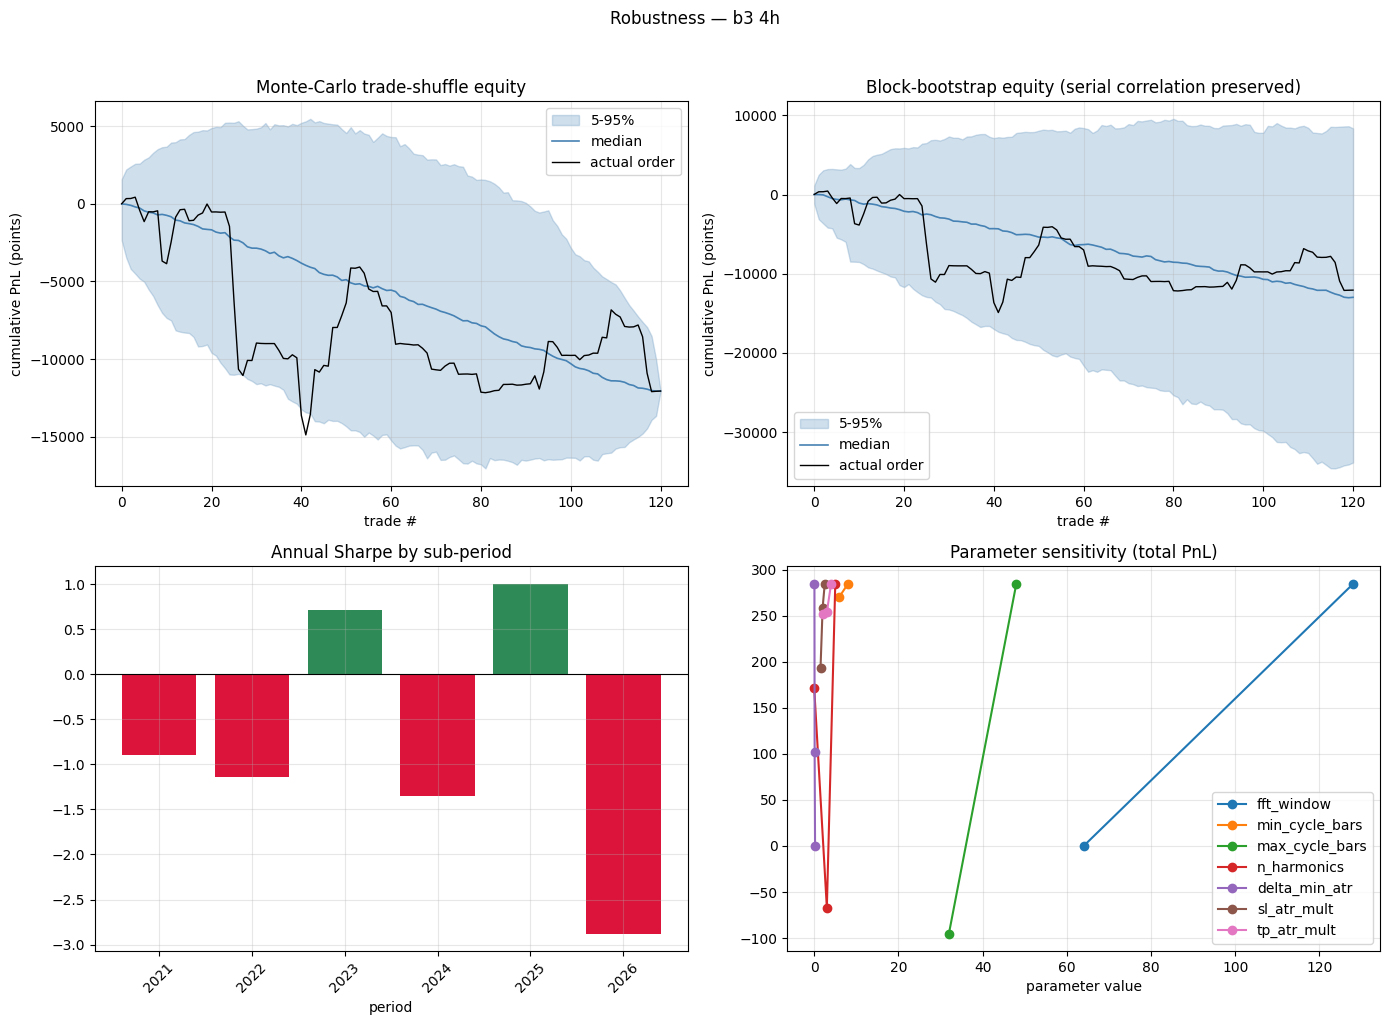

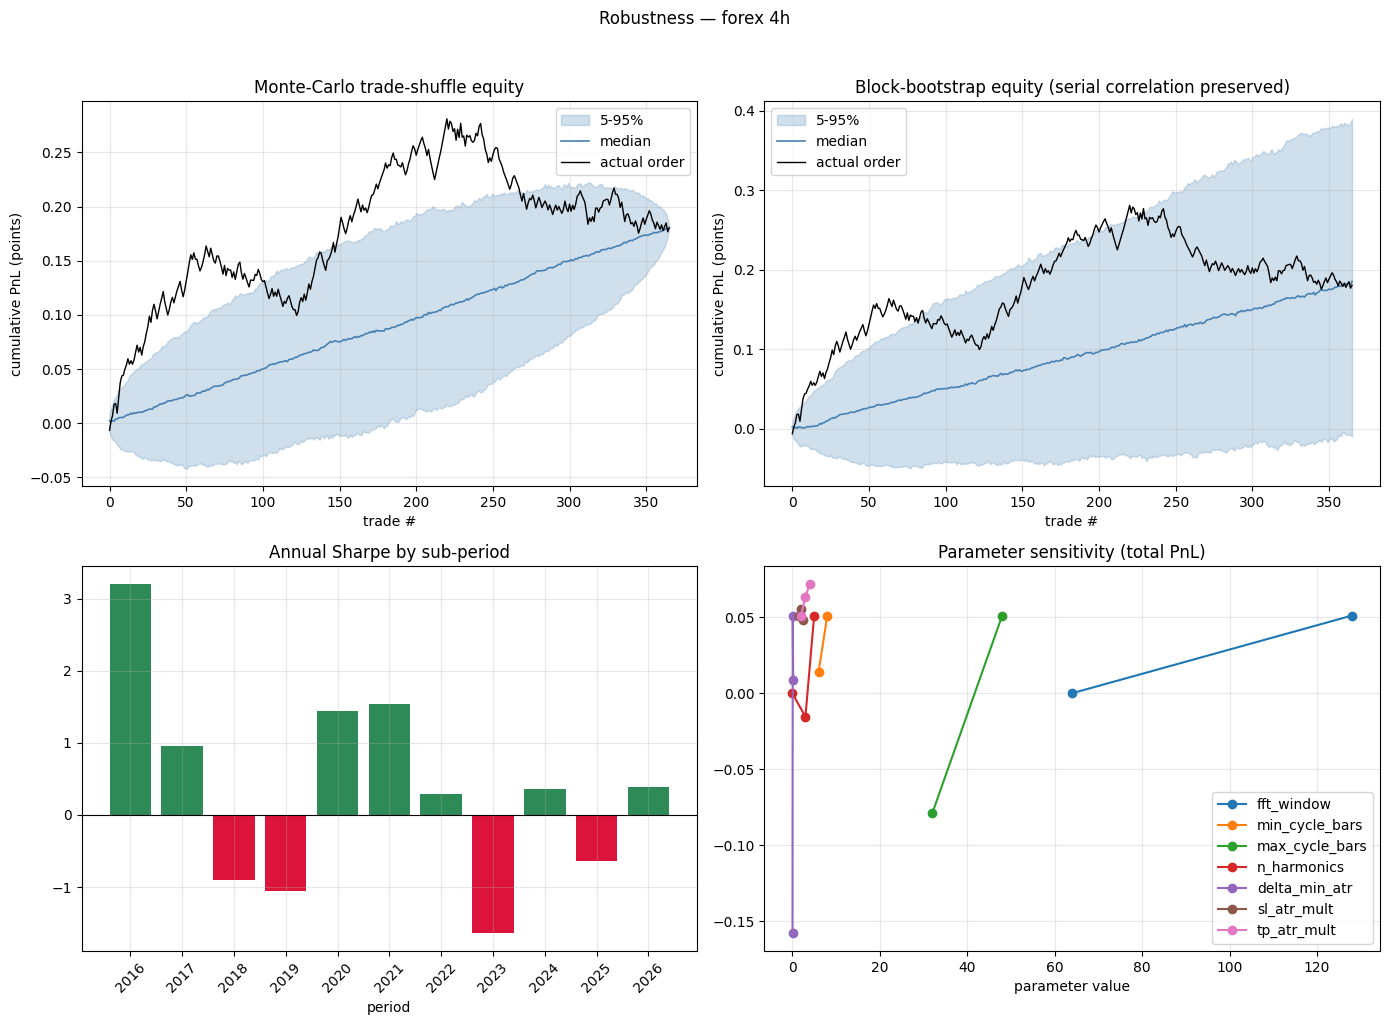

In [14]:
for group, tf in best_tfs.items():
    if tf is None or group not in mc_results or group not in sensitivity_results:
        continue
    opt_trades = optimized_portfolio[group][tf].trades
    if opt_trades.empty:
        continue
    mc_df, _ = mc_results[group]
    bs_df, _ = bootstrap_results[group]
    sens_df = sensitivity_results[group]
    sub_df = subperiod_results.get(group, pd.DataFrame())

    fig = plot_robustness_dashboard(
        mc_df=mc_df,
        baseline_equity=optimized_portfolio[group][tf].equity,
        sensitivity=sens_df,
        block_bootstrap_df=bs_df,
        subperiod_df=sub_df,
    )
    fig.suptitle(f"Robustness — {group} {tf}", y=1.02)
    plt.show()

## 6. Takeaways

_(To be filled in once the notebook has been executed and the §3/§4/§5 results are visible.)_

This notebook establishes a baseline for **FFT Cycle Filter & Forward Projection** on the available data groups using the parameter ranges in [`DocumentationVault/strategies/14_FFT_Cycle_Filter.md`](../DocumentationVault/strategies/14_FFT_Cycle_Filter.md). It shares the `Backtester`, `walk_forward`, and robustness helpers with the SMA and RSI baselines, so the §3 / §4 metrics tables can be compared directly across strategies.

Open items / known scope gaps:


**Scope deviations from the doc.**
- The dynamic phase-cycle exit and projection-reversal close are **not implemented** (`use_projection_exit`, `use_cycle_exit` are exposed but inert); needs a custom `Backtester` exit hook.
- The doc's `min_power_fraction` filter is implemented; default 0 keeps every in-band component.
- Edge stability: the in-window reconstruction uses **no Hann compensation** (since `hann ≈ 0` at the edge makes division unstable). The Hann-distorted value at `i = N-1` and the analytical projection at `i = N` are differenced — the *relative* delta is meaningful even if both are scaled by the window.
- Crypto group skipped (no local data).